In [1]:
import glob
import os

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

# import seaborn as sns
import palettable.colorbrewer.diverging as pld
import palettable as pt

import numpy as np
import pandas as pd

%matplotlib widget

In [2]:
plt.close('all')

In [3]:
## Plotting parameters

palette = pld.RdYlGn_4_r
# palette = pld.BlueGreen_4_r
palette = pld.Spectral_10_r
cmap = palette.mpl_colormap
cmap = plt.get_cmap('rainbow')
transparency = 0.7
labelsize = 20
spinewidth = 3
fontsize = 26
legendsize = 20
fontweight = 'bold'
labelpad = 6
pad = 10
linewidth = 2.5


In [4]:
import palettable
palette2 = palettable.colorbrewer.diverging.RdYlGn_8_r
RdYlGn_8_r = palette2.mpl_colormap
palette2.mpl_colors

[(0.10196078431372549, 0.596078431372549, 0.3137254901960784),
 (0.4, 0.7411764705882353, 0.38823529411764707),
 (0.6509803921568628, 0.8509803921568627, 0.41568627450980394),
 (0.8509803921568627, 0.9372549019607843, 0.5450980392156862),
 (0.996078431372549, 0.8784313725490196, 0.5450980392156862),
 (0.9921568627450981, 0.6823529411764706, 0.3803921568627451),
 (0.9568627450980393, 0.42745098039215684, 0.2627450980392157),
 (0.8431372549019608, 0.18823529411764706, 0.15294117647058825)]

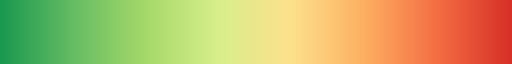

In [5]:
RdYlGn_8_r

In [6]:
palette2.hex_colors

['#1A9850',
 '#66BD63',
 '#A6D96A',
 '#D9EF8B',
 '#FEE08B',
 '#FDAE61',
 '#F46D43',
 '#D73027']

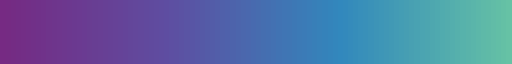

In [7]:
from matplotlib.colors import LinearSegmentedColormap
colors = [
    # (0.25098039215686274, 0.0, 0.29411764705882354), 
    (0.4627450980392157, 0.16470588235294117, 0.5137254901960784),
    (0.3686274509803922, 0.30980392156862746, 0.6352941176470588), 
    (0.19607843137254902, 0.5333333333333333, 0.7411764705882353), 
    (0.4, 0.7607843137254902, 0.6470588235294118),
 # (0.6705882352941176, 0.8666666666666667, 0.6431372549019608),
 # (0.6509803921568628, 0.8509803921568627, 0.41568627450980394),
 # (0.10196078431372549, 0.5882352941176471, 0.2549019607843137), 
         ]
BlGn = LinearSegmentedColormap.from_list('BlGn', colors, N=100)
BlGn

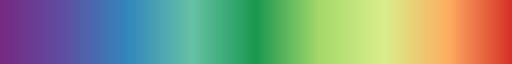

In [8]:
RdGnpu_mpl_colors: list = [
    (0.4627450980392157, 0.16470588235294117, 0.5137254901960784),
    (0.3686274509803922, 0.30980392156862746, 0.6352941176470588), 
    (0.19607843137254902, 0.5333333333333333, 0.7411764705882353), 
    (0.4, 0.7607843137254902, 0.6470588235294118),
    
    (0.10196078431372549, 0.596078431372549, 0.3137254901960784), 
    
    # (0.4, 0.7411764705882353, 0.38823529411764707), 
    (0.6509803921568628, 0.8509803921568627, 0.41568627450980394), 
    (0.8509803921568627, 0.9372549019607843, 0.5450980392156862), 
    # (0.996078431372549, 0.8784313725490196, 0.5450980392156862), 
    (0.9921568627450981, 0.6823529411764706, 0.3803921568627451), 
    # (0.9568627450980393, 0.42745098039215684, 0.2627450980392157), 
    (0.8431372549019608, 0.18823529411764706, 0.15294117647058825), 
]
RdGnpu = LinearSegmentedColormap.from_list('RdGnpu', RdGnpu_mpl_colors, N=10000)
RdGnpu

In [9]:
from matplotlib.colors import rgb_to_hsv, to_hex
k = 9 #len(data_keys)
color_idx = np.linspace(0, 1, k)

# palette = pt.colorbrewer.sequential.GnBu_9
# cmap = RdGnpu.mpl_colormap
cmap = RdGnpu

i = 0
for kk in color_idx:
    hex_ = to_hex(cmap(kk))
    print(f'{i = }, {kk = }, {hex_ = }')
    i += 1

i = 0, kk = 0.0, hex_ = '#762a83'
i = 1, kk = 0.125, hex_ = '#5e4fa2'
i = 2, kk = 0.25, hex_ = '#3288bd'
i = 3, kk = 0.375, hex_ = '#66c2a5'
i = 4, kk = 0.5, hex_ = '#1a9850'
i = 5, kk = 0.625, hex_ = '#a6d96a'
i = 6, kk = 0.75, hex_ = '#d9ef8b'
i = 7, kk = 0.875, hex_ = '#fdae61'
i = 8, kk = 1.0, hex_ = '#d73027'


## Find path of .fgr files (exported fitting results by PDFgui)

In [10]:
folder_base:str = '/Users/cheng-hunglin/Library/CloudStorage/GoogleDrive-chlin.tw1986@gmail.com/Other computers/My MacBook Pro/MAC_2015/Manuscript/In-Situ_Halide/processed_data_figures/'
figure_idx:str = 'Figure_5'
## Iodine
I_fgr_identifier:str = os.path.join(folder_base, figure_idx, '2023_03_05_23_Beamtime', 'Processed G_r', 'I_64.fgr')
I_fgr_path:list = glob.glob(I_fgr_identifier)

## Chloride
Cl_fgr_identifier:str = os.path.join(folder_base, figure_idx, '2022_06_15 Beamtime', 'Cl_64_single.fgr')
Cl_fgr_path:list = glob.glob(Cl_fgr_identifier)


# fgr_path.sort()
fgr_path:list = I_fgr_path + Cl_fgr_path
fgr_basename:list = [os.path.basename(n) for n in fgr_path]
print(*fgr_basename, sep='\n')

I_64.fgr
Cl_64_single.fgr


## Find path of G(r)

In [11]:
folder_base:str = '/Users/cheng-hunglin/Library/CloudStorage/GoogleDrive-chlin.tw1986@gmail.com/Other computers/My MacBook Pro/MAC_2015/Manuscript/In-Situ_Halide/processed_data_figures/'
figure_idx:str = 'Figure_5'

## Iodine
I64_gr_identifier:str = os.path.join(folder_base, figure_idx, '2023_03_05_23_Beamtime', 'Processed G_r', 'I_64.gr copy')
I64_gr_path:list = glob.glob(I64_gr_identifier)

## Chloride
Cl64_gr_identifier:str = os.path.join(folder_base, figure_idx, '2022_06_15 Beamtime', 'Cl_64.gr')
Cl64_gr_path:list = glob.glob(Cl64_gr_identifier)


# gr_path.sort()
gr_path:list = I64_gr_path + Cl64_gr_path
gr_basename:list = [os.path.basename(n) for n in gr_path]
print(*gr_basename, sep='\n')

I_64.gr copy
Cl_64.gr


## Organize data key and fgr path as a data dictonary 

In [12]:
data_keys:list = ['Cl_64', 'I_64'][::-1]
data_dict:dict = {}
for key in data_keys:
    for _path in fgr_path:
        basename = os.path.basename(_path)
        if key in basename:
            data_dict.update({key: _path})

data_dict

{'I_64': '/Users/cheng-hunglin/Library/CloudStorage/GoogleDrive-chlin.tw1986@gmail.com/Other computers/My MacBook Pro/MAC_2015/Manuscript/In-Situ_Halide/processed_data_figures/Figure_5/2023_03_05_23_Beamtime/Processed G_r/I_64.fgr',
 'Cl_64': '/Users/cheng-hunglin/Library/CloudStorage/GoogleDrive-chlin.tw1986@gmail.com/Other computers/My MacBook Pro/MAC_2015/Manuscript/In-Situ_Halide/processed_data_figures/Figure_5/2022_06_15 Beamtime/Cl_64_single.fgr'}

In [13]:
# data_keys:list = ['Cl_64micl', 'Cl_32micl', 'Cl_16micl', 'Cl_8micl', 'CsPbBr2_10m', 'I_8micl', 'I_16micl', 'I_32micl', 'I_64micl']
data_dict2:dict = {}
for key in data_keys:
    for _path in gr_path:
        basename = os.path.basename(_path)
        if key in basename:
            data_dict2.update({key: _path})

data_dict2

{'I_64': '/Users/cheng-hunglin/Library/CloudStorage/GoogleDrive-chlin.tw1986@gmail.com/Other computers/My MacBook Pro/MAC_2015/Manuscript/In-Situ_Halide/processed_data_figures/Figure_5/2023_03_05_23_Beamtime/Processed G_r/I_64.gr copy',
 'Cl_64': '/Users/cheng-hunglin/Library/CloudStorage/GoogleDrive-chlin.tw1986@gmail.com/Other computers/My MacBook Pro/MAC_2015/Manuscript/In-Situ_Halide/processed_data_figures/Figure_5/2022_06_15 Beamtime/Cl_64.gr'}

In [14]:
def is_float(s):    
    """
    Checks if a string can be successfully converted to a float.
    
    Args:
    s: The string to check.
    
    Returns:
    True if the string can be converted to a float, False otherwise.
    """
    try:
        float(s)
        return True
    except ValueError:
        return False

def get_HeaderRows(fn, sep=' ', num_data_column=2, check_range=100, check_float=True):

    cont_01 = []
    with open(fn, 'r') as f:
        cont = f.readlines()
        f.close()
    
    for line in cont:
        new_line = line.strip('\n').split(sep)
        cont_01.append(new_line)

    i = 0
    while i < len(cont_01):
        c0 = (len(cont_01[i]) == num_data_column)
        c1 = all([len(l)==num_data_column for l in cont_01[i:i+check_range]])
        c2 = (is_float(cont_01[i][0]) and is_float(cont_01[i][1]))

        if check_float:
            if c0 and c1 and c2:
                # print(f'Num of rows of header is {i}.')
                break
        else:
            if c0 and c1:
                # print(f'Num of rows of header is {i}.')
                break
            
        i += 1

    return i

In [15]:
def find_nearest(array, value):
    """find the nearest value in a given array

    Args:
        array (array_like): input array
        value (float): target value

    Returns:
        int: index of the nearest value in the array
        float: the nearest value in the array
    """
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

## Read fgr data into pandas

In [16]:
fgr_df:pd.DataFrame = pd.DataFrame()
fgr_df2:pd.DataFrame = pd.DataFrame()
for key, fn in data_dict.items():
    skiprows = get_HeaderRows(fn, sep=' ', num_data_column=5, check_range=100, check_float=True)
    df = pd.read_csv(fn, sep=' ', names=['r(A)', 'G(r)', 'd_r', 'd_Gr', 'Gdiff'], skiprows=skiprows)
    fgr_df[f'r_{key}'] = df['r(A)']
    fgr_df[f'g_{key}'] = df['G(r)']
    fgr_df[f'dr_{key}'] = df['d_r']
    fgr_df[f'dg_{key}'] = df['d_Gr']
    fgr_df[f'dif_{key}'] = df['Gdiff']

    fgr_df2[f'gr_{key}'] = df['G(r)']

fgr_df

,r_I_64,g_I_64,dr_I_64,dg_I_64,dif_I_64,r_Cl_64,g_Cl_64,dr_Cl_64,dg_Cl_64,dif_Cl_64
0,2.49,-0.097161,0.0,-0.054099,-0.054099,1.99,-0.107424,0.0,-0.203884,-0.203884
1,2.50,-0.108597,0.0,-0.041532,-0.041532,2.00,-0.123368,0.0,-0.189348,-0.189348
2,2.51,-0.119757,0.0,-0.029534,-0.029534,2.01,-0.139200,0.0,-0.175972,-0.175972
3,2.52,-0.130489,0.0,-0.018324,-0.018324,2.02,-0.154641,0.0,-0.164009,-0.164009
4,2.53,-0.140646,0.0,-0.008107,-0.008107,2.03,-0.169419,0.0,-0.153662,-0.153662
...,...,...,...,...,...,...,...,...,...,...
5747,59.96,0.002163,0.0,0.004314,0.004314,59.46,-0.044562,0.0,0.040791,0.040791
5748,59.97,0.002631,0.0,0.004463,0.004463,59.47,-0.044887,0.0,0.041372,0.041372
5749,59.98,0.003094,0.0,0.004627,0.004627,59.48,-0.045231,0.0,0.041924,0.041924
5750,59.99,0.003551,0.0,0.004806,0.004806,59.49,-0.045592,0.0,0.042446,0.042446


## Read gr data into pandas

In [17]:
gr_df:pd.DataFrame = pd.DataFrame()
gr_df2:pd.DataFrame = pd.DataFrame()
for key, fn in data_dict2.items():
    skiprows = get_HeaderRows(fn, sep=' ', num_data_column=2, check_range=100, check_float=True)
    df = pd.read_csv(fn, sep=' ', names=['r(A)', 'G(r)'], skiprows=skiprows)
    gr_df[f'r_{key}'] = df['r(A)']
    gr_df[f'g_{key}'] = df['G(r)']
    # fgr_df[f'dr_{key}'] = df['d_r']
    # fgr_df[f'dg_{key}'] = df['d_Gr']
    # fgr_df[f'dif_{key}'] = df['Gdiff']

    gr_df2[f'gr_{key}'] = df['G(r)']

gr_df

,r_I_64,g_I_64,r_Cl_64,g_Cl_64
0,0.00,0.000000,0.00,0.000000
1,0.01,-0.004546,0.01,-0.010667
2,0.02,-0.008910,0.02,-0.020801
3,0.03,-0.012922,0.03,-0.029920
4,0.04,-0.016420,0.04,-0.037593
...,...,...,...,...
9996,99.96,-0.002999,99.96,-0.000061
9997,99.97,-0.002970,99.97,-0.000100
9998,99.98,-0.002945,99.98,-0.000142
9999,99.99,-0.002923,99.99,-0.000186


## Plot data

In [18]:
gr_df[f'g_{data_keys[0]}']

0        0.000000
1       -0.004546
2       -0.008910
3       -0.012922
4       -0.016420
           ...   
9996    -0.002999
9997    -0.002970
9998    -0.002945
9999    -0.002923
10000   -0.002905
Name: g_I_64, Length: 10001, dtype: float64

In [19]:
marker_style = dict(color='tab:blue', linestyle=':', marker='o',
                    markersize=15, markerfacecoloralt='tab:red')
marker_style

{'color': 'tab:blue',
 'linestyle': ':',
 'marker': 'o',
 'markersize': 15,
 'markerfacecoloralt': 'tab:red'}

In [20]:
plt.close('all')

In [21]:
find_nearest(gr_df[f'r_{data_keys[0]}'], 50)

(5000, 50.0)

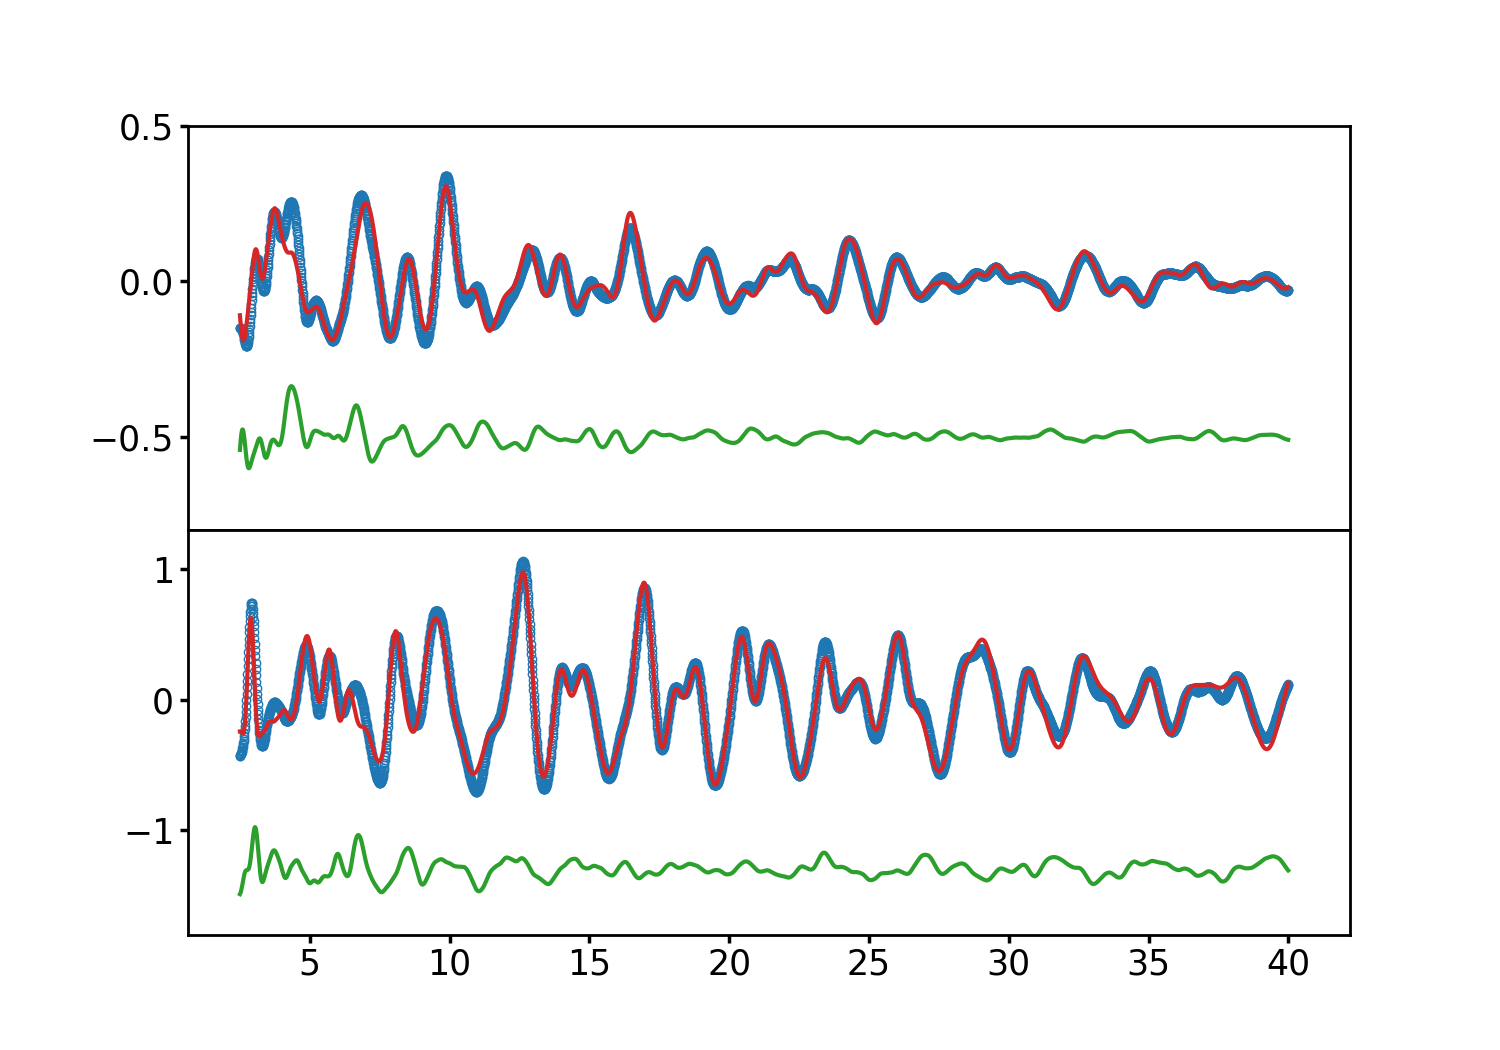

In [22]:
gs = GridSpec(nrows=2, ncols=1, height_ratios=[1.0, 1.0])
f0 = plt.figure(figsize=(15, 15*0.7),) #constrained_layout=True)
# ax0 = f0.add_subplot(gs[:,:])

k = len(data_keys)
color_idx = np.linspace(0, 1, k)

# palette = pt.colorbrewer.sequential.GnBu_9
# cmap = RdGnpu.mpl_colormap
cmap = RdGnpu

tick_font_size = 25
tick_width = 2.5
tick_length = 6.0
ax_linewidth = 2.0
linewidth = 3 #(1.5 for legend)

y_offset = 0.2
# x_min = 0
# x_max = 6000

for i in range(0, k, 1):
    
    ax0 = f0.add_subplot(gs[i,:])

    rmin = 2.5
    rmax = 40.0
    
    ## plot observed gr

    x_min, _ = find_nearest(gr_df[f'r_{data_keys[i]}'], rmin)
    x_max, _ = find_nearest(gr_df[f'r_{data_keys[i]}'], rmax)
    marker_style = dict(color='tab:blue', linestyle='None', marker='o',
                    markersize=3*2, fillstyle='none')
    ax0.plot(gr_df[f'r_{data_keys[i]}'].iloc[x_min:x_max], 
             gr_df[f'g_{data_keys[i]}'].iloc[x_min:x_max], 
             label='G obse',  
            **marker_style)


    ## plot calculated gr
    x_min, _ = find_nearest(fgr_df[f'r_{data_keys[i]}'], rmin)
    x_max, _ = find_nearest(fgr_df[f'r_{data_keys[i]}'], rmax)
    marker_style = dict(color='tab:red', linestyle='-', marker='None',
                    markersize=10, fillstyle='none')
    ax0.plot(fgr_df[f'r_{data_keys[i]}'].iloc[x_min:x_max], 
             fgr_df[f'g_{data_keys[i]}'].iloc[x_min:x_max], 
             label='G calc', linewidth=linewidth, 
            **marker_style)

    
    ## plot diff
    x_min, _ = find_nearest(fgr_df[f'r_{data_keys[i]}'], rmin)
    x_max, _ = find_nearest(fgr_df[f'r_{data_keys[i]}'], rmax)
    y_offset = -0.7
    
    if i == 0:
        y_offset = -0.5
        ax0.set_xticks([])
    elif i == 1:
        y_offset = -1.3
        
    marker_style = dict(color='tab:green', linestyle='-', marker='None',
                    markersize=10, fillstyle='none')
    ax0.plot(fgr_df[f'r_{data_keys[i]}'].iloc[x_min:x_max], 
             fgr_df[f'dif_{data_keys[i]}'].iloc[x_min:x_max]+y_offset, 
             label='G diff', linewidth=linewidth, 
            **marker_style)

    ax0.tick_params(labelsize=tick_font_size, width=tick_width, length=tick_length)

    for axis in ['top', 'bottom', 'left', 'right']:
        ax0.spines[axis].set_linewidth(ax_linewidth) # Set the thickness in points



ax0 = f0.get_axes()[0]
ax0.set_xlim(right=42.2)   
ax0.set_ylim(-0.8, 0.5)
# ax0.legend(bbox_to_anchor=(0.5, 1.2), ncol=3)


ax0 = f0.get_axes()[1]
ax0.set_xlim(right=42.2)   
ax0.set_ylim(-1.8, 1.3)

f0.subplots_adjust(hspace=0)
# ax0.legend(bbox_to_anchor=(1.0, 0.2), loc='lower left', ncol=1)
# ax0 = f0.add_subplot(gs[1,:])
# k = len(I_keys)
# color_idx = np.linspace(0, 1, k)

# palette = pt.colorbrewer.diverging.RdYlGn_11_r
# cmap = palette.mpl_colormap

# for i in range(0, k, 1):
#     ax0.plot(fgr_df[f'r_{I_keys[i]}'].iloc[x_min:x_max], 
#              fgr_df[f'g_{I_keys[i]}'].iloc[x_min:x_max]+y_offset*i, 
#              label=f'{I_keys[i]}', 
#              color=cmap(color_idx[i]))


In [23]:
fn_img = 'figure05_001.png'
f0.savefig(fn_img, transparent=True, dpi=600)

In [24]:
# plt.close('all')

In [25]:
from matplotlib.colors import rgb_to_hsv, to_hex
k = len(data_keys)
color_idx = np.linspace(0, 1, k)

# palette = pt.colorbrewer.sequential.GnBu_9
# cmap = RdGnpu.mpl_colormap
cmap = RdGnpu

i = 0
for kk in color_idx:
    hex_ = to_hex(cmap(kk))
    print(f'{i = }, {kk = }, {hex_ = }')
    i += 1

i = 0, kk = 0.0, hex_ = '#762a83'
i = 1, kk = 1.0, hex_ = '#d73027'


In [26]:
cmap(kk)[:3]

(0.8431372549019608, 0.18823529411764706, 0.15294117647058825)

In [27]:
plt.close('all')

In [28]:
data_keys

['I_64', 'Cl_64']